## Conditional Chains

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [2]:
class QuadState(TypedDict):
    a :int
    b :int 
    c :int
    equation : str
    discriminat : float
    result : str



In [21]:
def show_equation(state:QuadState) -> QuadState:
    equation = f"{state['a']}x2{state['b']}x{state['c']}"
    return {'equation':equation}

def calculate_discriminat(state:QuadState) -> QuadState:
    discriminant = state['b']**2 - (4*state['a']*state['c'])

    return {'discriminat':discriminant}

def real_roots(state:QuadState) -> QuadState:
    root1 = (-state['b'] + state['discriminat']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminat']**0.5)/(2*state['a'])

    result = f"The roots are {root1} and {root2}"

    return {'result':result}

def repeated_root(state:QuadState) -> QuadState:
    root1 = (-state['b']) /(2*state['a'])

    result = f"Only repaeating root is {root1}"

    return {'result':result}

def no_real_root(state:QuadState) -> QuadState:

    result = f"No real roots"

    return {'result':result}

def check_condition(state:QuadState) ->Literal["real_roots","repeated_root","no_real_root"]:
    if state['discriminat'] > 0:
        return "real_roots"
    elif state['discriminat'] == 0:
        return "repeated_root"
    else:
        return "no_real_root"

In [23]:
graph = StateGraph(QuadState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminat)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_root",repeated_root)
graph.add_node("no_real_root",no_real_root)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant",check_condition)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_root",END)
graph.add_edge("no_real_root",END)



workflow = graph.compile()

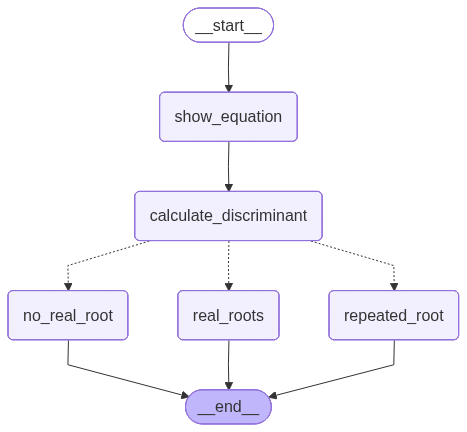

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [31]:
inital_value = {
    'a':-4,
    'b':22,
    'c':-4
}

In [32]:
workflow.invoke(inital_value)

{'a': -4,
 'b': 22,
 'c': -4,
 'equation': '-4x222x-4',
 'discriminat': 420,
 'result': 'The roots are 0.1882623085101005 and 5.311737691489899'}